## Textbook code

In [3]:
import numpy as np
import sys
import os
sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet


# 4.5.2 미니배치 학습 구현하기
# * 주의 : 아주 오래 걸림 *
"""
60000개의 훈련 데이터에서 임의로 100개의 데이터(이미지&정답 레이블)을 추려냄.
100개의 미니배치를 대상으로 확률적 경사 하강법을 수행해 매개변수를 갱신한다.
경사법에 의한 갱신 횟수를 1000번으로 설정하고 갱신할 때마다 손실 함수를 계산한다.
"""
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=False)

# 하이퍼 파라메터
iters_num = 10_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

train_loss_list = []
train_acc_list = []
test_acc_list = []

# 1에폭당 반복 수
iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    print(i)
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    # grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)  # 다음 장에서 구현할 더 빠른 방법!

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭 당 정확도 계산
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | "
              + str(train_acc) + ", " + str(test_acc))

# print(train_loss_list)


# 4.5.3 시험 데이터로 평가하기
"""
위의 계산에서 손실 함수의 값이 점점 감소하게 되는데, 이때의 손실 함수는
훈련 데이터의 미니배치에 대한 손실 함수를 말한다.
훈련 데이터 외의 데이터를 올바르게 인식하는지(오버피팅이 일어나지 않았는지) 확인 필요.
1 에폭별로 훈련 데이터와 시험 데이터에 대한 정확도를 기록하도록 수정.
에폭epoch : 학습에서 훈련 데이터를 모두 소진했을 때의 횟수.
10000개를 100개의 미니배치로 학슬할 경우 100회가 1에폭이 된다.

훈련 데이터와 시험 데이터의 정확도 추이가 비슷하다면 오버피팅이 일어나지 않은 것이다.
오버피팅이 발생했다면, 어느 순간부터 시험 데이터에 대한 정확도가 떨어지기 시작한다.
오버피팅이 발생하기 전에 학습을 중단해 오버피팅을 예방하는 기법을 조기 종료early stopping라고 한다.
"""


0
train acc, test acc | 0.12826666666666667, 0.1299
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264


'\n위의 계산에서 손실 함수의 값이 점점 감소하게 되는데, 이때의 손실 함수는\n훈련 데이터의 미니배치에 대한 손실 함수를 말한다.\n훈련 데이터 외의 데이터를 올바르게 인식하는지(오버피팅이 일어나지 않았는지) 확인 필요.\n1 에폭별로 훈련 데이터와 시험 데이터에 대한 정확도를 기록하도록 수정.\n에폭epoch : 학습에서 훈련 데이터를 모두 소진했을 때의 횟수.\n10000개를 100개의 미니배치로 학슬할 경우 100회가 1에폭이 된다.\n\n훈련 데이터와 시험 데이터의 정확도 추이가 비슷하다면 오버피팅이 일어나지 않은 것이다.\n오버피팅이 발생했다면, 어느 순간부터 시험 데이터에 대한 정확도가 떨어지기 시작한다.\n오버피팅이 발생하기 전에 학습을 중단해 오버피팅을 예방하는 기법을 조기 종료early stopping라고 한다.\n'

In [ ]:
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

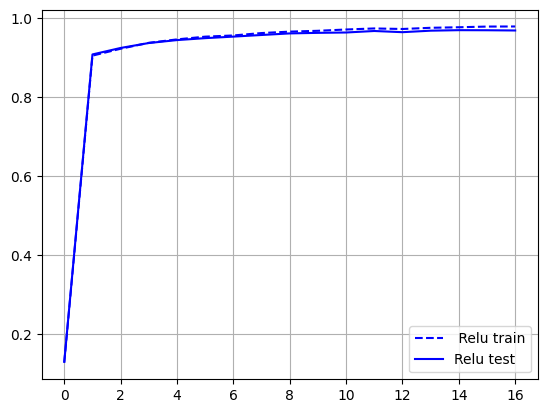

In [10]:
import matplotlib.pyplot as plt
plt.plot(train_acc_list, linestyle='dashed', color='b', label=' Relu train')
plt.plot(test_acc_list, linestyle='solid', color='b', label='Relu test')
plt.grid()
plt.legend()

## My code

In [28]:
import sys
import os

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [29]:
# 데이터 읽기
(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=False, one_hot_label=False)

In [30]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)
print(np.average(x_train), np.average(x_test))


(60000, 784)
255
(60000,)
33.318421449829934 33.791224489795916


In [31]:
x_train = (x_train - np.mean(x_train))/np.std(x_train)
x_test = (x_test - np.mean(x_test))/np.std(x_test)

In [32]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)
print(np.average(x_train), np.average(x_test))

(60000, 784)
2.821543345689335
(60000,)
-3.064638490070051e-17 8.980933910384103e-17


In [33]:
network_dict = {
                'step': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='step', weight_init_std=0.01),
                'sigmoid': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='sigmoid', weight_init_std=0.01),
                'tanh': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='tanh', weight_init_std=0.01),
                'relu': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='relu', weight_init_std=0.01),
                'leaky': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std=0.01),
                }

In [34]:
network_dict['relu'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2'])

In [35]:
# 하이퍼 파라메터
iters_num = 10_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [36]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== step network training start ===
--- step result report ---
train acc, test acc | 0.1517, 0.1505
--- step result report ---
train acc, test acc | 0.7929, 0.8046
--- step result report ---
train acc, test acc | 0.8073166666666667, 0.8193
--- step result report ---
train acc, test acc | 0.8122833333333334, 0.8214
--- step result report ---
train acc, test acc | 0.8161833333333334, 0.824
--- step result report ---
train acc, test acc | 0.8172666666666667, 0.8261
--- step result report ---
train acc, test acc | 0.8192166666666667, 0.8268
--- step result report ---
train acc, test acc | 0.81905, 0.8277
--- step result report ---
train acc, test acc | 0.8197166666666666, 0.827
--- step result report ---
train acc, test acc | 0.8214833333333333, 0.8287
--- step result report ---
train acc, test acc | 0.8219666666666666, 0.8287
--- step result report ---
train acc, test acc | 0.8216166666666667, 0.8282
--- step result report ---
train acc, test acc | 0.8222833333333334, 0.8278
--- step resu

step train acc
step test acc
sigmoid train acc
sigmoid test acc
tanh train acc
tanh test acc
relu train acc
relu test acc
leaky train acc
leaky test acc


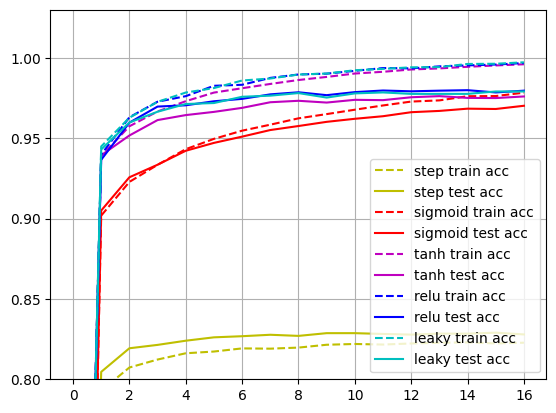

In [45]:
for k, v in output_dict.items():
    print(k)
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        

plt.ylim([0.8, 1.03])   
plt.legend()
plt.grid()